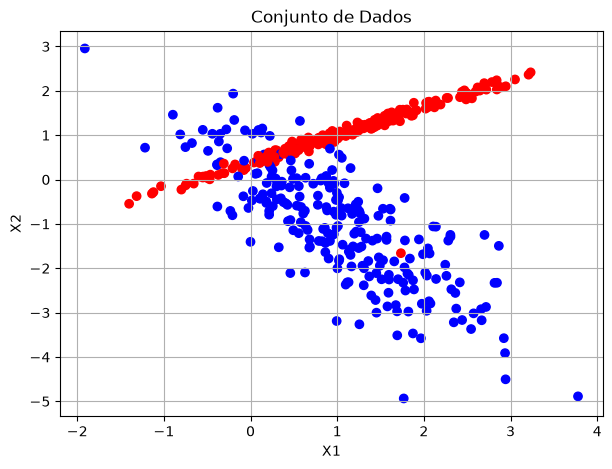

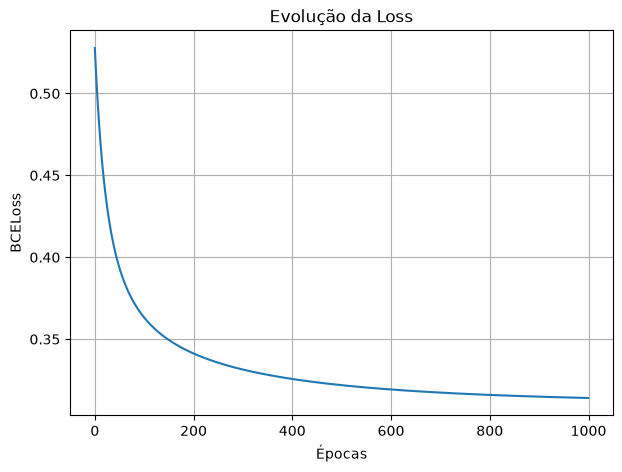

RESULTADOS
Acurácia: 86.00%


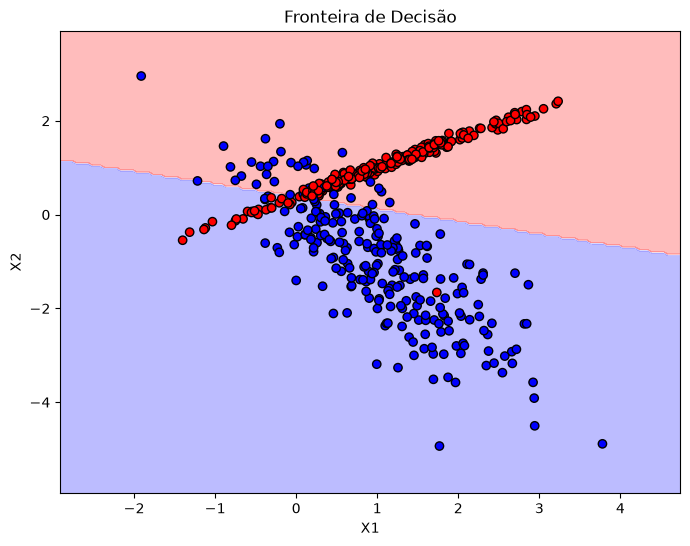


Pesos aprendidos:
0.weight
tensor([[0.5970, 2.2398]])
0.bias
tensor([-0.8583])


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim

# ==========================================================
# 1. Gerando os dados
# ==========================================================

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr")
plt.title("Conjunto de Dados")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True)
plt.show()

# ==========================================================
# 2. Divisão treino/teste
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# ==========================================================
# 3. Conversão para Tensores
# ==========================================================

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train.reshape(-1,1))
y_test = torch.FloatTensor(y_test.reshape(-1,1))

# ==========================================================
# 4. Modelo de Regressão Logística
# ==========================================================

model = nn.Sequential(
    nn.Linear(2,1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()

optimizer = optim.SGD(model.parameters(), lr=0.05)

# ==========================================================
# 5. Treinamento
# ==========================================================

epochs = 1000

losses = []

for epoch in range(epochs):

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

# ==========================================================
# 6. Gráfico da Loss
# ==========================================================

plt.figure(figsize=(7,5))
plt.plot(losses)
plt.title("Evolução da Loss")
plt.xlabel("Épocas")
plt.ylabel("BCELoss")
plt.grid(True)
plt.show()

# ==========================================================
# 7. Avaliação
# ==========================================================

with torch.no_grad():

    probabilities = model(X_test)

    predictions = (probabilities >= 0.5).float()

accuracy = accuracy_score(
    y_test.numpy(),
    predictions.numpy()
)

print("="*50)
print("RESULTADOS")
print("="*50)
print(f"Acurácia: {accuracy*100:.2f}%")

# ==========================================================
# 8. Fronteira de decisão
# ==========================================================

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.05),
    np.arange(y_min, y_max, 0.05)
)

grid = np.c_[xx.ravel(), yy.ravel()]

grid_tensor = torch.FloatTensor(grid)

with torch.no_grad():
    Z = model(grid_tensor)
    Z = (Z >= 0.5).float().numpy()

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="bwr")

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="bwr",
    edgecolors="k"
)

plt.title("Fronteira de Decisão")
plt.xlabel("X1")
plt.ylabel("X2")

plt.show()

# ==========================================================
# 9. Pesos aprendidos
# ==========================================================

print("\nPesos aprendidos:")

for name, param in model.named_parameters():
    print(name)
    print(param.data)